<div style="background:linear-gradient(135deg,#0d1117 0%,#161b22 100%);padding:32px;border-radius:12px;border-left:5px solid #58a6ff;">
<h1 style="color:#e6edf3;margin:0;font-size:28px;">Calidad del aire en Santiago</h1>
<p style="color:#58a6ff;margin:8px 0 0;font-size:15px;font-weight:600;">Proyecto transversal MCDI500 &mdash; Fase 1 &middot; Grupo 3</p>
<p style="color:#8b949e;margin:14px 0 0;font-size:14px;line-height:1.6;">An&aacute;lisis exploratorio de la relaci&oacute;n entre variables meteorol&oacute;gicas y los episodios cr&iacute;ticos de contaminaci&oacute;n por material particulado (MP2.5 / MP10) en la Regi&oacute;n Metropolitana.</p>
</div>

**Pregunta de investigaci&oacute;n:** &iquest;Qu&eacute; condiciones meteorol&oacute;gicas anticipan un episodio cr&iacute;tico de contaminaci&oacute;n por material particulado en Santiago?

Este notebook documenta la carga, limpieza y exploraci&oacute;n de los datos del SINCA. Cada decisi&oacute;n t&eacute;cnica queda registrada en celdas de texto (markdown) y el procesamiento en celdas de c&oacute;digo, asegurando **trazabilidad y reproducibilidad**.

---
## 1. Configuraci&oacute;n del entorno

Importamos las librer&iacute;as y definimos un estilo visual consistente para todo el notebook.

In [92]:
#Librerías para manipulación de datos
import pandas as pd
#Librerías para manipulación de datos numéricos
import numpy as np
import os
#librerías para graficar
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# Paleta y estilo premium (tema oscuro)
COL = {
    'fondo': '#0d1117', 'texto': '#e6edf3', 'sub': '#8b949e',
    'grid': '#21262d', 'acento': '#58a6ff', 'alerta': '#f85149',
    'ok': '#3fb950', 'warn': '#d29922',
}
plt.rcParams.update({
    'figure.facecolor': COL['fondo'], 'axes.facecolor': COL['fondo'],
    'savefig.facecolor': COL['fondo'], 'axes.edgecolor': COL['grid'],
    'axes.labelcolor': COL['texto'], 'text.color': COL['texto'],
    'xtick.color': COL['sub'], 'ytick.color': COL['sub'],
    'grid.color': COL['grid'], 'grid.alpha': 0.6,
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'axes.grid': True, 'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 110,
})
print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Inspecci&oacute;n del archivo crudo

Antes de cargar, se revisan las primeras l&iacute;neas del CSV para confirmar el separador y la codificaci&oacute;n. Los archivos del SINCA usan punto y coma (`;`) como separador y coma decimal.

In [93]:
#Se carga el dataset para revisar su estructura
ruta = '../data/raw/sinca_santiago.csv'
with open(ruta, encoding='latin-1') as f:
    for i in range(4):
        print(i, repr(f.readline()))


0 'fecha;estacion;comuna;MP2.5;MP10;temperatura;humedad;presion;viento;radiacion;inversion_termica;dia_semana;es_finde;es_festivo\n'
1 '01-01-2022 00:00;Pudahuel;Pudahuel;20,9;47,3;20,2;51,9;1016,9;1,9;35,0;1;5;1;1\n'
2 '01-01-2022 01:00;Pudahuel;Pudahuel;5,1;19,1;17,2;57,3;1019,4;2,9;28,0;0;5;1;1\n'
3 '01-01-2022 02:00;Pudahuel;Pudahuel;5,0;18,8;14,6;56,1;1016,3;2,7;52,0;0;5;1;1\n'


---
## 3. Carga de los datos
Se especifica `sep=';'`, `decimal=','` y `encoding='latin-1'` (formato SINCA). Se convierte la columna `fecha` a tipo datetime y se deriva las variables temporales para el an&aacute;lisis. Se está trabajando con magnitudes físicas, por lo tanto se es necesario analizarlas con sus respectivas unidades de medidas

In [94]:

# Carga optimizada del CSV con pandas, especificando separador, decimal y encoding
df = pd.read_csv(ruta, sep=';', decimal=',', encoding='latin-1')

# Limpieza de filas fantasmas/vacías por si acaso
df = df.dropna(how='all')

#configuración de la fecha, con manejo de errores para formatos mixtos
try:
    df['fecha'] = pd.to_datetime(df['fecha'], format='mixed', cache=True)
    df['fecha'] = df['fecha'].dt.floor('h')
except Exception as e:
    print(f"Aviso con datetime automático: {e}. Aplicando plan B...")
    df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
    df['fecha'] = df['fecha'].dt.floor('h')

#diccionarios para mapear las variables cualitativas y cuantitativas, con sus unidades
dicc_columnas = {
    'MP2.5': ['µg/m³', 'cuantitativo'],
    'MP10': ['µg/m³', 'cuantitativo'],
    'temperatura': ['°C', 'cuantitativo'],
    'humedad': ['%', 'cuantitativo'],
    'presion': ['hPa', 'cuantitativo'],
    'viento': ['m/s', 'cuantitativo'],
    'radiacion': ['W/m²', 'cuantitativo'],
    'inversion_termica': ['','cualitativo'],
    'dia_semana': ['','cualitativo'],
    'es_finde': ['', 'cualitativo'],
    'es_festivo': ['', 'cualitativo'],
    'fecha': [' ', 'temporal'],
    'estacion': ['', 'cualitativo'],
    'comuna': ['', 'cualitativo']
}

dicc_dias_semana = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'}
dicc_booleano = {0: 'No', 1: 'Sí'}   

# mapeo en el ddcionario para las variables cualitativas, aplicando .map() que es más eficiente que .apply()
mapeos = {
    'dia_semana': dicc_dias_semana,
    'es_finde': dicc_booleano,
    'es_festivo': dicc_booleano,
    'inversion_termica': dicc_booleano
}
# reemplazo de valores según diccionario
for col, dicc in mapeos.items():
    if col in df.columns:
        # Usamos .map() que trabaja a nivel de memoria C
        df[col] = df[col].map(dicc)
        
# nuevos encabezados con unidades para las variables cuantitativas, aplicando comprensión de diccionario
nuevos_encabezados = {
    col: f"{col} ({valores[0]})" if valores[0].strip() else col
    for col, valores in dicc_columnas.items()
    if col in df.columns
}
df.rename(columns=nuevos_encabezados, inplace=True)


#convertir la fecha a formato de texto con AM/PM
df['fecha'] = pd.to_datetime(df['fecha']).dt.strftime('%Y-%m-%d %I:%M %p')
df.head()

,fecha,estacion,comuna,MP2.5 (µg/m³),MP10 (µg/m³),temperatura (°C),humedad (%),presion (hPa),viento (m/s),radiacion (W/m²),inversion_termica,dia_semana,es_finde,es_festivo
0,2022-01-01 12:00 AM,Pudahuel,Pudahuel,20.9,47.3,20.2,51.9,1016.9,1.9,35.0,Sí,Sábado,Sí,Sí
1,2022-01-01 01:00 AM,Pudahuel,Pudahuel,5.1,19.1,17.2,57.3,1019.4,2.9,28.0,No,Sábado,Sí,Sí
2,2022-01-01 02:00 AM,Pudahuel,Pudahuel,5.0,18.8,14.6,56.1,1016.3,2.7,52.0,No,Sábado,Sí,Sí
3,2022-01-01 03:00 AM,Pudahuel,Pudahuel,2.0,14.1,14.5,59.7,1014.5,3.4,0.0,No,Sábado,Sí,Sí
4,2022-01-01 04:00 AM,Pudahuel,Pudahuel,11.9,27.7,16.8,54.9,1020.6,0.9,2.0,No,Sábado,Sí,Sí


---
## 4. Inspecci&oacute;n general y calidad de los datos

Se revisan los tipos de datos, estad&iacute;sticas descriptivas y valores faltantes antes de limpiar.

In [95]:
df.info()
df.describe().round(1)

<class 'pandas.DataFrame'>
RangeIndex: 192720 entries, 0 to 192719
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   fecha              192720 non-null  str    
 1   estacion           192720 non-null  str    
 2   comuna             192720 non-null  str    
 3   MP2.5 (µg/m³)      189830 non-null  float64
 4   MP10 (µg/m³)       189830 non-null  float64
 5   temperatura (°C)   192720 non-null  float64
 6   humedad (%)        189830 non-null  float64
 7   presion (hPa)      189830 non-null  float64
 8   viento (m/s)       192720 non-null  float64
 9   radiacion (W/m²)   189830 non-null  float64
 10  inversion_termica  192720 non-null  str    
 11  dia_semana         192720 non-null  str    
 12  es_finde           192720 non-null  str    
 13  es_festivo         192720 non-null  str    
dtypes: float64(7), str(7)
memory usage: 30.3 MB


,MP2.5 (µg/m³),MP10 (µg/m³),temperatura (°C),humedad (%),presion (hPa),viento (m/s),radiacion (W/m²)
count,189830.0,189830.0,192720.0,189830.0,189830.0,192720.0,189830.0
mean,26.2,54.5,14.0,62.2,1013.0,3.1,307.0
std,18.6,30.5,7.8,9.7,4.1,1.6,387.2
min,2.0,5.4,-4.0,21.4,996.6,0.2,0.0
25%,10.5,28.4,8.4,55.6,1010.1,2.0,0.0
50%,24.4,50.8,14.0,62.2,1013.0,2.9,43.0
75%,39.0,75.0,19.6,68.7,1015.9,4.0,584.0
max,97.4,184.0,35.0,100.0,1028.9,15.8,1417.0


---
## 5. Limpieza de datos

La cantidad de datos por magnitudes son distintas. Cocnsiderando los factores estadísticos se concluye que todas las magnitudes físicas tienen un comportamiento simetrico porque sus medianas son similares a sus medias, a excepción de la radiación. Por lo tanto en vez de agregar medias a las celdas faltantes, se realiza una limpieza del dataset.

In [96]:
# Actualización de dataset con limpieza de filas con valores nulos o vacíos, para asegurar que el análisis se base en datos completos
df = df.dropna()
df.info()
df.describe().round(1)

<class 'pandas.DataFrame'>
Index: 178709 entries, 0 to 192719
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   fecha              178709 non-null  str    
 1   estacion           178709 non-null  str    
 2   comuna             178709 non-null  str    
 3   MP2.5 (µg/m³)      178709 non-null  float64
 4   MP10 (µg/m³)       178709 non-null  float64
 5   temperatura (°C)   178709 non-null  float64
 6   humedad (%)        178709 non-null  float64
 7   presion (hPa)      178709 non-null  float64
 8   viento (m/s)       178709 non-null  float64
 9   radiacion (W/m²)   178709 non-null  float64
 10  inversion_termica  178709 non-null  str    
 11  dia_semana         178709 non-null  str    
 12  es_finde           178709 non-null  str    
 13  es_festivo         178709 non-null  str    
dtypes: float64(7), str(7)
memory usage: 29.6 MB


,MP2.5 (µg/m³),MP10 (µg/m³),temperatura (°C),humedad (%),presion (hPa),viento (m/s),radiacion (W/m²)
count,178709.0,178709.0,178709.0,178709.0,178709.0,178709.0,178709.0
mean,26.2,54.5,14.0,62.2,1013.0,3.1,307.3
std,18.6,30.5,7.8,9.7,4.1,1.6,387.3
min,2.0,5.4,-4.0,21.4,996.6,0.2,0.0
25%,10.4,28.3,8.4,55.6,1010.1,2.0,0.0
50%,24.4,50.8,14.0,62.2,1013.0,2.9,43.0
75%,38.9,75.0,19.6,68.7,1015.9,4.0,584.0
max,97.4,184.0,35.0,100.0,1028.9,15.7,1417.0


Se logra observar en la descripción que con la limpieza se tiene un dataset limpio.

---
## 6. Definici&oacute;n de episodio cr&iacute;tico

Existen 2 posibles episodios críticos: El primero es un MP2.5 promedio diario superior a 49 (µg/m³) y el segundo es un MP10 promedio diario superior a 179(µg/m³). Ambos umbrales son concentraciones necesarias para un aire regular. Con estos 2 episodios críticos se podrá definir condiciones meteorológicas y anticipar una alerta. La Normativa ambiental chilena exige que un promedio diario mínimo se calcule con 18Hr. Por lo tanto hay que eliminar filas asociadas a días con menos de 18 hrs muestreados

In [97]:
# Convertir la columna 'fecha' al tipo datetime si aún no lo está
df['fecha'] = pd.to_datetime(df['fecha'])

# Crear una columna temporal solo con la fecha (AAAA-MM-DD) para agrupar por día
df['solo_fecha'] = df['fecha'].dt.date

# Filtrar el DataFrame manteniendo solo los grupos que tienen 18 o más registros
df_filtrado = df.groupby(['solo_fecha', 'comuna']).filter(lambda x: len(x) >= 18)

# Eliminar la columna temporal si ya no la necesitas
df_filtrado = df_filtrado.drop(columns=['solo_fecha'])

# Verificar cuántos datos quedaron
print(f"Registros originales: {len(df)}")
print(f"Registros después del filtro: {len(df_filtrado)}")
df_filtrado.head()

C:\Users\grave\AppData\Local\Temp\ipykernel_14380\3426668773.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['fecha'] = pd.to_datetime(df['fecha'])


Registros originales: 178709
Registros después del filtro: 178558


,fecha,estacion,comuna,MP2.5 (µg/m³),MP10 (µg/m³),temperatura (°C),humedad (%),presion (hPa),viento (m/s),radiacion (W/m²),inversion_termica,dia_semana,es_finde,es_festivo
0,2022-01-01 00:00:00,Pudahuel,Pudahuel,20.9,47.3,20.2,51.9,1016.9,1.9,35.0,Sí,Sábado,Sí,Sí
1,2022-01-01 01:00:00,Pudahuel,Pudahuel,5.1,19.1,17.2,57.3,1019.4,2.9,28.0,No,Sábado,Sí,Sí
2,2022-01-01 02:00:00,Pudahuel,Pudahuel,5.0,18.8,14.6,56.1,1016.3,2.7,52.0,No,Sábado,Sí,Sí
3,2022-01-01 03:00:00,Pudahuel,Pudahuel,2.0,14.1,14.5,59.7,1014.5,3.4,0.0,No,Sábado,Sí,Sí
4,2022-01-01 04:00:00,Pudahuel,Pudahuel,11.9,27.7,16.8,54.9,1020.6,0.9,2.0,No,Sábado,Sí,Sí


In [98]:
import pandas as pd

# 1. Asegurar formato de fecha en el set original
df_filtrado["fecha"] = pd.to_datetime(df_filtrado["fecha"])
df_filtrado["solo_fecha"] = df_filtrado["fecha"].dt.date

UMBRAL25 = 49
UMBRAL10 = 179

# Cálculo del promedio diadio real para mp2.5 y mp10, agrupando por día, comuna y estación

mp25_diario = (
    df_filtrado.groupby(["solo_fecha", "comuna", "estacion"])
    .agg({"MP2.5 (µg/m³)": "mean"})
    .reset_index()
    .rename(columns={"MP2.5 (µg/m³)": "MP2.5_promedio_diario"})
)

mp10_diario = (
    df_filtrado.groupby(["solo_fecha", "comuna", "estacion"])
    .agg({"MP10 (µg/m³)": "mean"})
    .reset_index()
    .rename(columns={"MP10 (µg/m³)": "MP10_promedio_diario"})
)

# Segregación de días críticos según umbrales establecidos para MP2.5 y MP10

mp25_critico = mp25_diario[
    mp25_diario["MP2.5_promedio_diario"] > UMBRAL25
].sort_values(by=["solo_fecha", "comuna"])

mp10_critico = mp10_diario[
    mp10_diario["MP10_promedio_diario"] > UMBRAL10
].sort_values(by=["solo_fecha", "comuna"])

# Visualización de resultados

print(f"\nTotal de días analizados: {len(mp25_diario)}")
print(f"MP2.5 > {UMBRAL25} µg/m³: {len(mp25_critico)} días | MP10 > {UMBRAL10} µg/m³: {len(mp10_critico)} días")



Total de días analizados: 8021
MP2.5 > 49 µg/m³: 305 días | MP10 > 179 µg/m³: 0 días


Considerando que MP10 no tuvo ningún día, se analizará solo MP2.5.

---
## 7. Panel exploratorio

Se realizan gráficos para visualizar el comportamiento de la variable de estudio: Su eolución con respecto a las otras magitudes, su comportamiento frente a inversión térmica, fin de semanas y días festivos, su comportamiento diario y su comportamiento mensual.

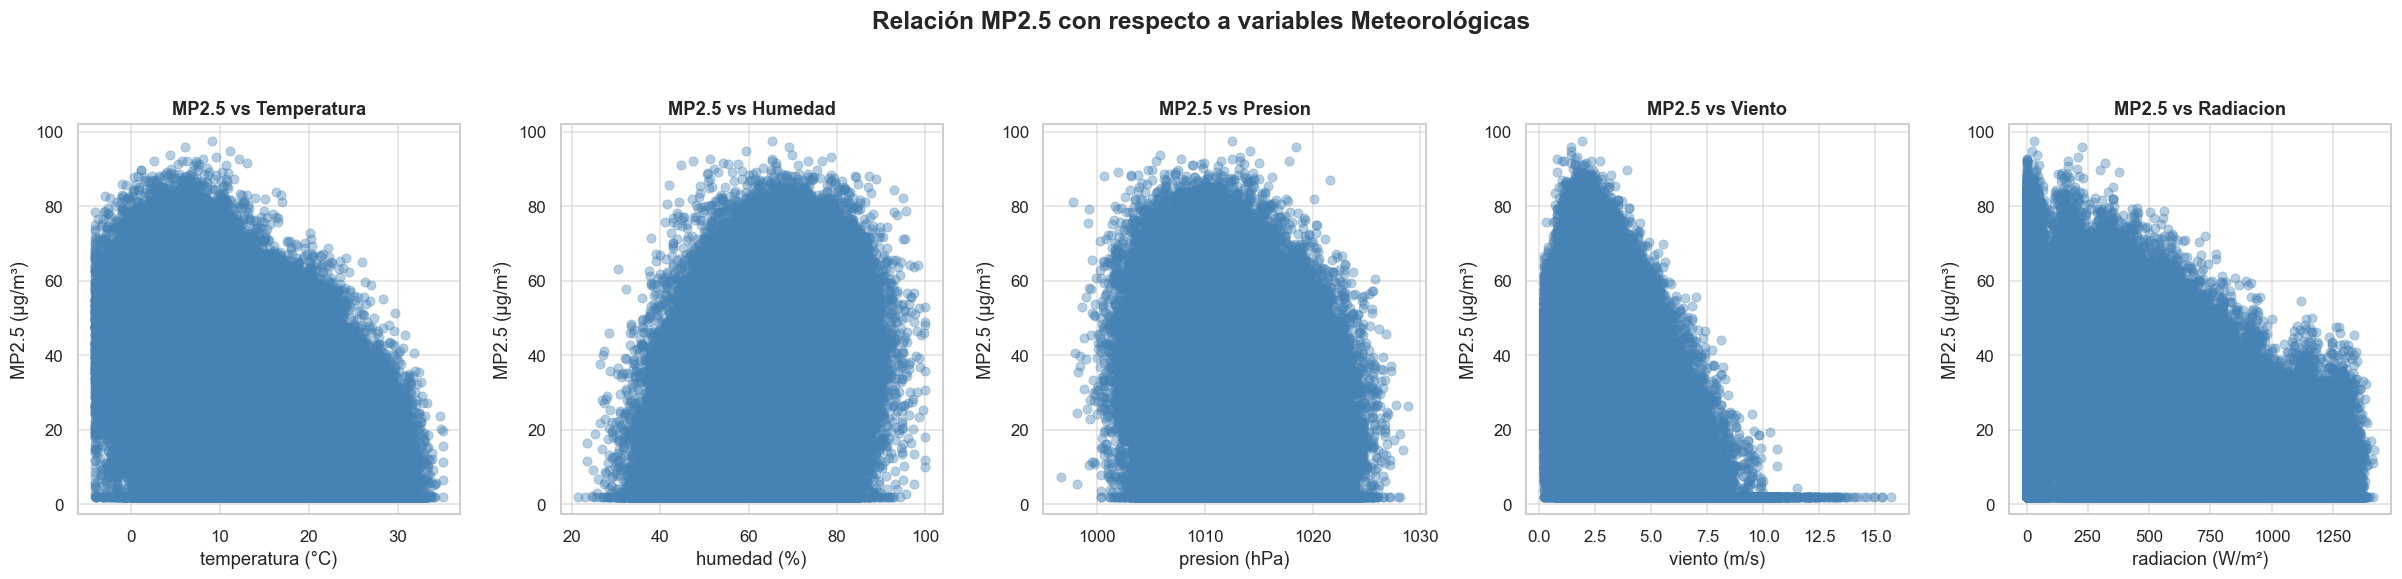

In [99]:
 #Configuración de estilo global
sns.set_theme(style="whitegrid")

# Procesamiento de fechas obligatorio para todo el análisis
df_filtrado["fecha"] = pd.to_datetime(df_filtrado["fecha"])
df_filtrado["Año-Mes"] = df_filtrado["fecha"].dt.to_period("M").astype(str)

# MAgnitudes núméricas
variables_num = [
    "temperatura (°C)",
    "humedad (%)",
    "presion (hPa)",
    "viento (m/s)",
    "radiacion (W/m²)",
]

# Volvemos a 1 fila y 5 columnas para enfocarnos solo en MP2.5
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for i, var in enumerate(variables_num):
    sns.scatterplot(
        data=df_filtrado,
        x=var,
        y="MP2.5 (µg/m³)",
        ax=axes[i],
        alpha=0.4,
        color="steelblue",
        edgecolor=None,
    )
    axes[i].set_title(f"MP2.5 vs {var.split(' ')[0].capitalize()}")
    axes[i].set_xlabel(var)  # La etiqueta X ahora va directamente en cada gráfico
    if i == 0:
        axes[i].set_ylabel("MP2.5 (µg/m³)")

plt.suptitle(
    "Relación MP2.5 con respecto a variables Meteorológicas",
    fontsize=16,
    weight="bold",
    y=1.05, 
)
plt.tight_layout()
plt.show()



C:\Users\grave\AppData\Local\Temp\ipykernel_14380\2588939600.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\grave\AppData\Local\Temp\ipykernel_14380\2588939600.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\grave\AppData\Local\Temp\ipykernel_14380\2588939600.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


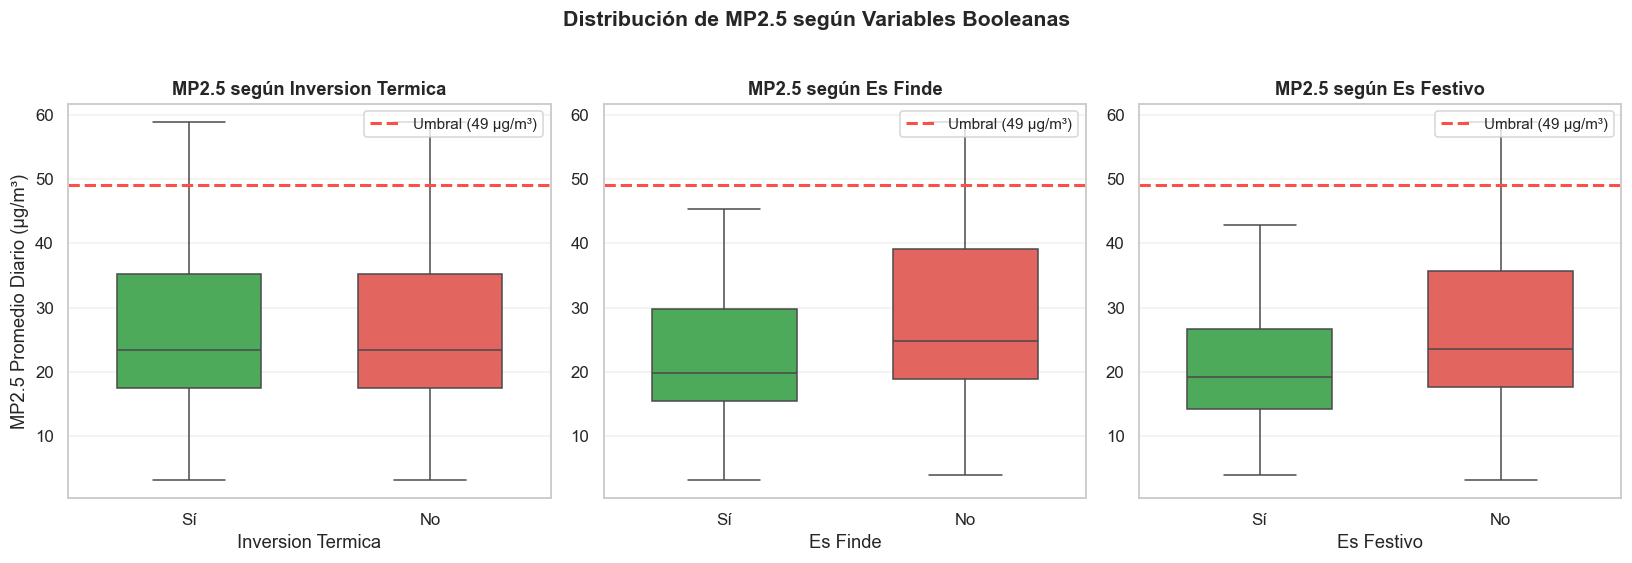

In [100]:
# Crear figura con subplots para cada variable booleana
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

variables_bool = ['inversion_termica', 'es_finde', 'es_festivo']

for idx, var in enumerate(variables_bool):
    sns.boxplot(
        data=mp25_diario_con_boolean,
        x=var,
        y='MP2.5_promedio_diario',
        ax=axes[idx],
        palette=['#3fb950','#f85149'],
        width=0.6
    )
    axes[idx].set_title(f'MP2.5 según {var.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(var.replace('_', ' ').title())
    axes[idx].set_ylabel('MP2.5 Promedio Diario (µg/m³)' if idx == 0 else '')
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Distribución de MP2.5 según Variables Booleanas', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
# Agregar línea roja punteada del umbral en cada gráfico
for idx, ax in enumerate(axes):
    ax.axhline(UMBRAL25, color=COL['alerta'], linestyle='--', linewidth=2, label=f'Umbral ({UMBRAL25} µg/m³)')
    ax.legend(loc='upper right', fontsize=10)

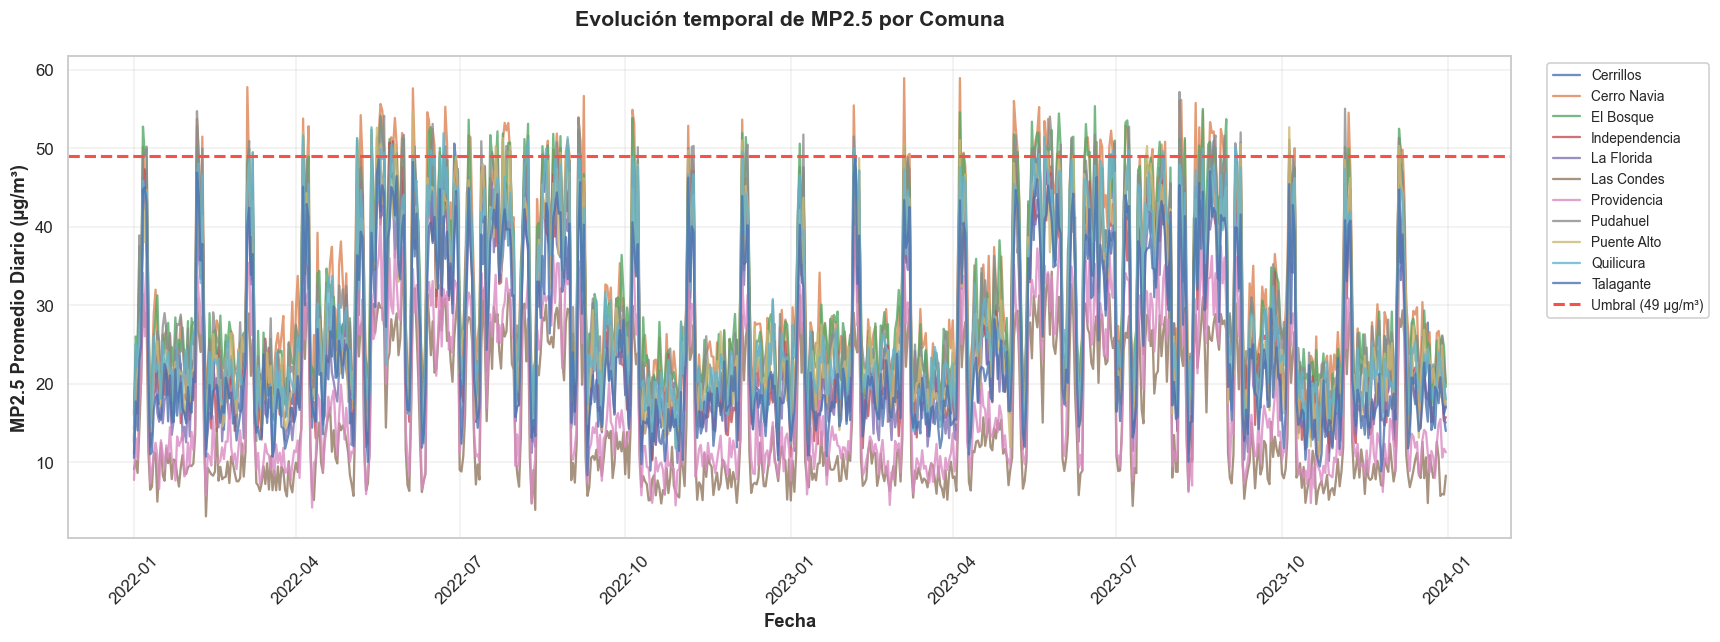

In [101]:
# Gráfico de evolución temporal de MP2.5 por comuna
fig, ax = plt.subplots(figsize=(14, 6))

# Obtener lista única de comunas
comunas = mp25_diario['comuna'].unique()

# Imprimir una línea por cada comuna
for comuna in sorted(comunas):
    datos_comuna = mp25_diario[mp25_diario['comuna'] == comuna].sort_values('solo_fecha')
    ax.plot(
        datos_comuna['solo_fecha'],
        datos_comuna['MP2.5_promedio_diario'],
        label=comuna,
        linewidth=1.5,
        alpha=0.8
    )

# Añadir línea de umbral
ax.axhline(UMBRAL25, color=COL['alerta'], linestyle='--', linewidth=2, label=f'Umbral ({UMBRAL25} µg/m³)')

ax.set_xlabel('Fecha', fontsize=12, fontweight='bold')
ax.set_ylabel('MP2.5 Promedio Diario (µg/m³)', fontsize=12, fontweight='bold')
ax.set_title('Evolución temporal de MP2.5 por Comuna', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper left', fontsize=9, ncol=2, framealpha=0.95)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9, ncol=1, framealpha=0.95)

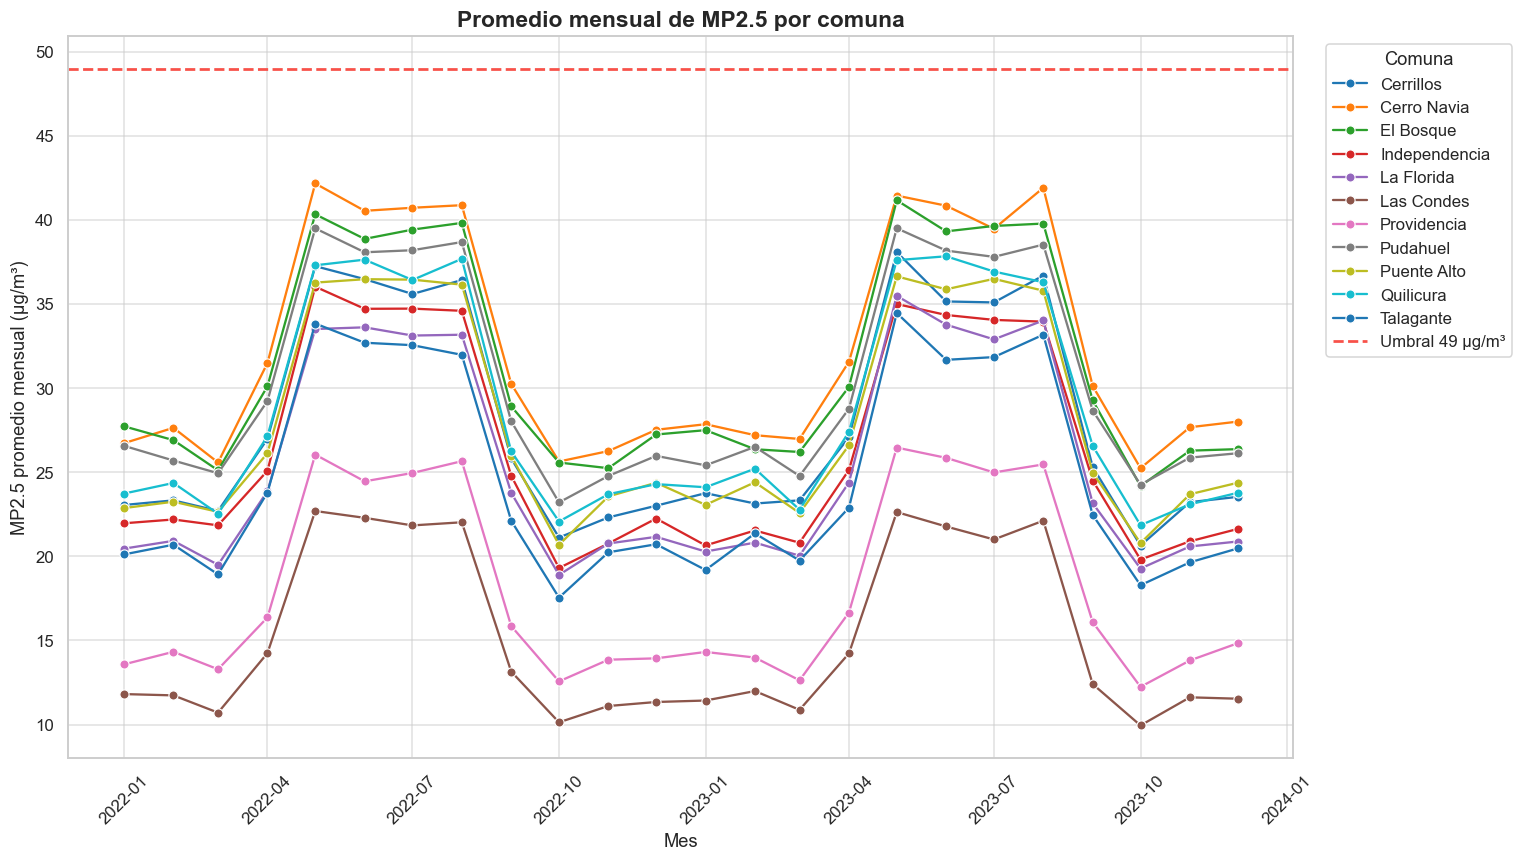

In [102]:
# Asegurar formato de la columna de tiempo original
df_filtrado['fecha'] = pd.to_datetime(df['fecha'])

# Crear una copia de trabajo y extraer el inicio de mes
mp25_mensual_plot = df.copy()
mp25_mensual_plot['mes'] = mp25_mensual_plot['fecha'].dt.to_period('M').dt.to_timestamp()

# Agrupar seleccionandola comuna, el mes y el valor numérico
mp25_mensual_plot = mp25_mensual_plot.groupby(['comuna', 'mes'])['MP2.5 (µg/m³)'].mean().reset_index()

# Renombrar la columna resultante para el gráfico
mp25_mensual_plot = mp25_mensual_plot.rename(columns={'MP2.5 (µg/m³)': 'MP2.5_promedio_mensual'})

# Ordenar cronológicamente
mp25_mensual_plot = mp25_mensual_plot.sort_values(['comuna', 'mes'])

fig, ax = plt.subplots(figsize=(14, 8))

sns.lineplot(
    data=mp25_mensual_plot,
    x='mes',
    y='MP2.5_promedio_mensual',
    hue='comuna',
    marker='o',
    linewidth=1.5,
    ax=ax,
    palette='tab10'
)

ax.axhline(UMBRAL25, color=COL['alerta'], linestyle='--', linewidth=1.8,
           label=f'Umbral {UMBRAL25} µg/m³')

ax.set_title('Promedio mensual de MP2.5 por comuna', fontsize=15, fontweight='bold')
ax.set_xlabel('Mes', fontsize=12)
ax.set_ylabel('MP2.5 promedio mensual (µg/m³)', fontsize=12)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Comuna', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()



---
## 8. Correlaci&oacute;n entre variables

Mapa de calor que cuantifica la relaci&oacute;n lineal entre el MP2.5 y cada variable meteorol&oacute;gica.

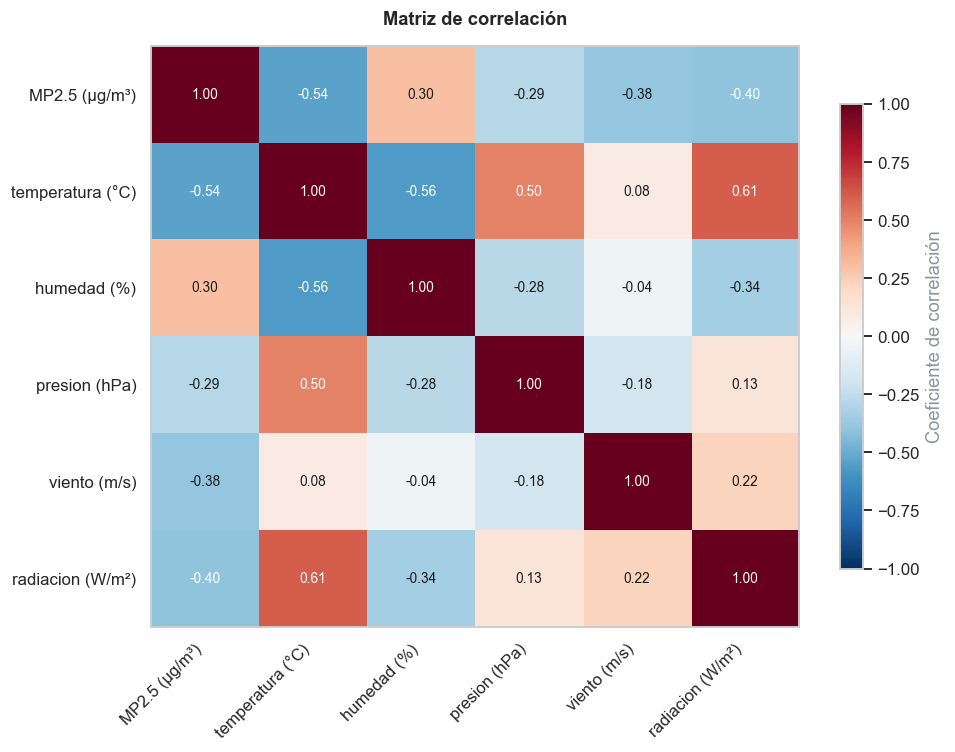

In [103]:
vars_corr = ['MP2.5 (µg/m³)', 'temperatura (°C)', 'humedad (%)', 'presion (hPa)',
             'viento (m/s)', 'radiacion (W/m²)']
corr = df[vars_corr].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(vars_corr)))
ax.set_yticks(range(len(vars_corr)))
ax.set_xticklabels(vars_corr, rotation=45, ha='right')
ax.set_yticklabels(vars_corr)

# Anotar cada celda con su valor
for i in range(len(vars_corr)):
    for j in range(len(vars_corr)):
        v = corr.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                color='white' if abs(v) > 0.4 else '#1c1c1c', fontsize=9)

cb = fig.colorbar(im, ax=ax, shrink=0.8)
cb.set_label('Coeficiente de correlación', color=COL['sub'])
ax.set_title('Matriz de correlación', pad=14)
ax.grid(False)
plt.tight_layout()
plt.show()

Del mapa de calor se observa que las correlaciones entre M2.5 y el resto de magnitudes físicas son débiles. 

---
## 9. Condiciones que anticipan un episodio cr&iacute;tico

Con la visualización y limpieza del dataset en esta instancia del proyecto no se pueden definir condiciones las condiciones a partir de las magnitudes físicas asociadas. Lo que si se puede asegurar es que, para días con inversión térmica, días festivos y fin de semanas no hay riesgo de sobrepasar el umbral

---
## 10. Conclusiones preliminares

Considerando la visualización de los datos realizados en este documneto se puede observar que no se puede predecir MP2.5 a partir de una sola magnitud física lo que hace necesario evaluar su comportamiento con otras herramientas, concretamente la variable que mayor correlación presenta es la temperatura. Además se observa un aumento en el promedio mensual en la estación de invierno, esto se debe a que en este periodo hay mayor consumo de dispositivos para la calefacción que afectan a la calidad de aire. Por último se logra apreciar que para días festivos y fin de semanas el materiar particulado no supera el umbral debido a que son días con menos traslado de personas y operaciones laborales